# Mercado Inmobiliario Danés 1992–2024
## Análisis de Hipótesis con datos reales (Kaggle)

**Dataset:** [Danish Residential Housing Prices 1992-2024](https://www.kaggle.com/datasets/martinfrederiksen/danish-residential-housing-prices-1992-2024/data)  
**Carga:** vía `mlcroissant`

---
### Hipótesis a contrastar
| # | Hipótesis |
|---|-----------|
| **H1** | Relación negativa entre `yield_on_mortgage_credit_bonds` y volumen transaccional, con rezago 1–2 trimestres (match funding) |
| **H2** | Copenhague muestra respuesta de precios más amortiguada ante shocks macro que Jutlandia (oferta restringida) |
| **H3** | Las Summerhouses exhiben drawdowns pico-valle más profundos y rápidos que viviendas primarias en recesiones |


## 0. Instalación de dependencias

In [1]:
!pip install -q mlcroissant pandas numpy matplotlib seaborn scipy statsmodels
print("✅ Dependencias instaladas")

✅ Dependencias instaladas


## 1. Imports y configuración global

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings, itertools
warnings.filterwarnings("ignore")

PALETTE = {
    "copenhagen": "#1a6bb5",
    "jutland":    "#e05c2e",
    "summerhouse":"#e8a020",
    "primary":    "#2e4d7b",
    "recession":  "#d94f4f",
    "bg":         "#f7f7f5",
    "grid":       "#dcdcdc",
}
plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"],  "axes.facecolor": PALETTE["bg"],
    "axes.edgecolor":   "#aaaaaa",      "axes.grid":      True,
    "grid.color":       PALETTE["grid"],"grid.linewidth": 0.6,
    "font.family":      "DejaVu Sans",  "axes.titlesize": 13,
    "axes.labelsize":   11,             "xtick.labelsize":9,
    "ytick.labelsize":  9,              "legend.fontsize":9,
    "figure.dpi":       120,
})

RECESSIONS = [
    ("1992-01-01", "1993-12-31"),
    ("2007-10-01", "2012-09-30"),
    ("2020-01-01", "2020-09-30"),
    ("2022-01-01", "2023-06-30"),
]
def add_recession_bands(ax, alpha=0.08):
    for s, e in RECESSIONS:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                   color=PALETTE["recession"], alpha=alpha, zorder=0)

SHOCK_MARKERS = [
    ("1995-01-01", "1995"),
    ("2008-07-01", "2008 Q3"),
    ("2020-04-01", "2020 Q2"),
    ("2022-01-01", "2022 Q1"),
]
def add_shock_markers(ax, show_labels=True):
    add_recession_bands(ax)
    for date_str, label in SHOCK_MARKERS:
        ts = pd.Timestamp(date_str)
        ax.axvline(ts, color=PALETTE["recession"], ls="--", lw=1.2, alpha=0.7, zorder=1)
        if show_labels:
            ax.text(ts, ax.get_ylim()[1] * 0.97, label,
                    rotation=90, va="top", ha="right", fontsize=7,
                    color=PALETTE["recession"], alpha=0.8)

print("✅ Configuración lista")

✅ Configuración lista


## 2. Carga del dataset vía Croissant

No se necesitan credenciales. `mlcroissant` descarga directamente la muestra de 100k filas
que Kaggle expone como `DKHousingPricesSample100k.csv`.


In [3]:
import mlcroissant as mlc

CROISSANT_URL = (
    "https://www.kaggle.com/datasets/"
    "martinfrederiksen/danish-residential-housing-prices-1992-2024"
    "/croissant/download"
)

print("⏳ Conectando con Kaggle via Croissant...")
dataset   = mlc.Dataset(CROISSANT_URL)
rs_name   = dataset.metadata.record_sets[0].name
print(f"   Record set: {rs_name}")

print("⏳ Descargando datos (36 MB aprox.)...")
records = dataset.records(record_set=rs_name)
df_raw  = pd.DataFrame(list(records))

# Limpiar prefijos que añade Croissant
df_raw.columns = [c.split("/")[-1] for c in df_raw.columns]

print(f"✅ Descarga completa: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head(3)


⏳ Conectando con Kaggle via Croissant...


  -  [Metadata(Danish Residential Housing Prices 1992-2024)] Property "http://mlcommons.org/croissant/citeAs" is recommended, but does not exist.


   Record set: DKHousingPricesSample100k.csv
⏳ Descargando datos (36 MB aprox.)...


✅ Descarga completa: 100,000 filas × 19 columnas


,date,quarter,house_id,house_type,sales_type,year_build,purchase_price,%25_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,city,area,region,nom_interest_rate%25,dk_ann_infl_rate%25,yield_on_mortgage_credit_bonds%25
0,2024-10-24,b'2024Q4',b'16',b'Villa',b'regular_sale',1997,6500000,-3.0,5,142.0,45774.65,b'Sp\xc3\xa6ttevej 16',2680,b'Solr\xc3\xb8d Strand',"b'Capital, Copenhagen'",b'Zealand',3.1,NaN,NaN
1,2024-10-24,b'2024Q4',b'13',b'Apartment',b'regular_sale',1885,3400000,0.0,2,46.0,73913.05,"b'Jakob Dannef\xc3\xa6rds Vej 10B, 4. th'",1973,b'Frederiksberg C',"b'Capital, Copenhagen'",b'Zealand',3.1,NaN,NaN
2,2024-10-23,b'2024Q4',b'60',b'Villa',b'regular_sale',1949,4550000,-4.0,4,112.0,40625.00,b'Vestre Plantagevej 3',2680,b'Solr\xc3\xb8d Strand',"b'Capital, Copenhagen'",b'Zealand',3.1,NaN,NaN


In [4]:
df_raw1  = pd.DataFrame(list(records))
df_raw1.columns = [c.split("/")[-1] for c in df_raw1.columns]
df_raw1.isnull().sum()

date                                      0
quarter                                   0
house_id                                  0
house_type                                0
sales_type                                0
year_build                                0
purchase_price                            0
%25_change_between_offer_and_purchase     0
no_rooms                                  0
sqm                                       0
sqm_price                                 0
address                                   0
zip_code                                  0
city                                     11
area                                      0
region                                    0
nom_interest_rate%25                      0
dk_ann_infl_rate%25                      77
yield_on_mortgage_credit_bonds%25        77
dtype: int64

In [5]:
df_raw1.dtypes

date                                     datetime64[us]
quarter                                          object
house_id                                         object
house_type                                       object
sales_type                                       object
year_build                                        int64
purchase_price                                    int64
%25_change_between_offer_and_purchase           float64
no_rooms                                          int64
sqm                                             float64
sqm_price                                       float64
address                                          object
zip_code                                          int64
city                                             object
area                                             object
region                                           object
nom_interest_rate%25                            float64
dk_ann_infl_rate%25                             

In [6]:
df_raw1.describe()


,date,year_build,purchase_price,%25_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,zip_code,nom_interest_rate%25,dk_ann_infl_rate%25,yield_on_mortgage_credit_bonds%25
count,100000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,99923.000000,99923.000000
mean,2012-10-28 09:36:46.656000,1955.078530,1.925992e+06,-2.084740,4.375790,129.387820,16406.648074,5951.612680,1.679263,1.927025,4.107445
min,1992-01-05 00:00:00,1000.000000,2.502000e+05,-49.000000,1.000000,26.000000,374.549800,1051.000000,0.000000,0.250000,1.100000
25%,2005-09-21 00:00:00,1931.000000,8.000000e+05,-3.000000,3.000000,89.000000,6792.940775,4000.000000,0.000000,0.790000,2.120000
50%,2015-03-31 00:00:00,1966.000000,1.400000e+06,0.000000,4.000000,123.000000,12070.707000,5970.000000,0.750000,1.850000,4.340000
75%,2020-09-24 00:00:00,1980.000000,2.450000e+06,0.000000,5.000000,160.000000,21343.201500,8250.000000,3.250000,2.340000,5.500000
max,2024-10-24 00:00:00,2024.000000,4.595500e+07,49.000000,15.000000,984.000000,75000.000000,9990.000000,9.500000,7.700000,10.140000
std,NaN,45.703585,1.777832e+06,4.852926,1.661686,57.170619,13655.184405,2369.938171,2.048078,1.638440,2.194428


## 3. Limpieza y normalización

Las columnas vienen con prefijos `b'...'` en strings (artefacto de Croissant).
También renombramos las columnas con `%25` a nombres limpios.


In [7]:
def clean_bytes(val):
    """Convierte b'...' strings a str normal."""
    if isinstance(val, bytes):
        return val.decode("utf-8", errors="replace")
    if isinstance(val, str) and val.startswith("b'"):
        return val[2:-1]
    return val

# Columnas de texto que tienen el prefijo b'...'
str_cols = ["quarter", "house_id", "house_type", "sales_type",
            "address", "city", "area", "region"]
for col in str_cols:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].apply(clean_bytes)

# Renombrar columnas con %25 → nombres legibles
df_raw.rename(columns={
    "%25_change_between_offer_and_purchase": "pct_offer_vs_purchase",
    "nom_interest_rate%25":                  "nom_interest_rate",
    "dk_ann_infl_rate%25":                   "dk_infl_rate",
    "yield_on_mortgage_credit_bonds%25":     "bond_yield",
}, inplace=True)

# Asegurar tipos
df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce")
df_raw["year"]    = df_raw["date"].dt.year
df_raw["quarter_num"] = df_raw["date"].dt.quarter

# Solo ventas regulares (excluir subastas y ventas familiares)
df = df_raw[df_raw["sales_type"] == "regular_sale"].copy()
df = df.dropna(subset=["date", "sqm_price", "region", "house_type"]).copy()
df = df.sort_values("date").reset_index(drop=True)

print(f"Filas tras filtro regular_sale: {len(df):,}")
print(f"\nRegiones:      {sorted(df['region'].unique())}")
print(f"Tipos de casa: {sorted(df['house_type'].unique())}")
print(f"Periodo:       {df['date'].min().date()} → {df['date'].max().date()}")
df[["date","house_type","region","sqm_price","bond_yield"]].describe()


Filas tras filtro regular_sale: 88,232

Regiones:      ['Bornholm', 'Fyn & islands', 'Jutland', 'Zealand']
Tipos de casa: ['Apartment', 'Farm', 'Summerhouse', 'Townhouse', 'Villa']
Periodo:       1992-01-05 → 2024-10-24


,date,sqm_price,bond_yield
count,88232,88232.000000,88167.000000
mean,2012-12-17 09:10:01.251246,16780.301388,4.081413
min,1992-01-05 00:00:00,380.467000,1.100000
25%,2005-10-04 00:00:00,7104.533875,2.120000
50%,2015-06-25 00:00:00,12513.292500,4.340000
75%,2020-11-09 00:00:00,21916.140250,5.500000
max,2024-10-24 00:00:00,75000.000000,10.140000
std,NaN,13632.636152,2.195451


## 4. Preprocesamiento: series trimestrales

Las regiones reales del dataset son: `Zealand`, `Jutland`, `Fyn & islands`, `Bornholm`.  
Para H2 usamos **Zealand** (incluye Copenhague) vs **Jutland**.


In [8]:
# ── Mapeo de regiones para H2 ────────────────────────────────────────────────
REGION_MAP = {
    "Zealand":       "Copenhagen/Zealand",
    "Jutland":       "Jutland",
    "Fyn & islands": "Fyn & islands",
    "Bornholm":      "Bornholm",
}
df["region_clean"] = df["region"].map(REGION_MAP).fillna(df["region"])

HOUSE_TYPE_MAP = {
    "Villa":       "House",
    "Apartment":   "Apartment",
    "Summerhouse": "Summerhouse",
    "Farm":        "Farm",
    "Terraced":    "House",
}
df["house_type_clean"] = df["house_type"].map(HOUSE_TYPE_MAP).fillna(df["house_type"])

# ── Fecha de trimestre ────────────────────────────────────────────────────────
df["quarter_date"] = df["date"].dt.to_period("Q").dt.to_timestamp()

# ── Deflación a DKK reales (base 2024) ────────────────────────────────────────
CPI_BASE_YEAR = 2024

cpi_q = (df.groupby("quarter_date")["dk_infl_rate"]
           .median()
           .sort_index()
           .reset_index()
           .rename(columns={"dk_infl_rate": "infl_rate"}))
cpi_q["quarterly_factor"] = (1 + cpi_q["infl_rate"].fillna(0) / 100) ** 0.25
cpi_q["cpi_index"] = cpi_q["quarterly_factor"].cumprod()

base_rows = cpi_q[cpi_q["quarter_date"].dt.year == CPI_BASE_YEAR]
cpi_base = base_rows["cpi_index"].iloc[-1] if len(base_rows) > 0 else cpi_q["cpi_index"].iloc[-1]

df = df.merge(cpi_q[["quarter_date", "cpi_index"]], on="quarter_date", how="left")
df["deflator"] = cpi_base / df["cpi_index"]
df["real_purchase_price"] = df["purchase_price"] * df["deflator"]
df["real_sqm_price"]      = df["sqm_price"]      * df["deflator"]

print(f"Deflación aplicada (base {CPI_BASE_YEAR})")
print(f"  CPI rango: {cpi_q['cpi_index'].iloc[0]:.4f} → {cpi_q['cpi_index'].iloc[-1]:.4f}")

# ── Agregación trimestral con precios reales ──────────────────────────────────
agg = (df.groupby(["quarter_date", "year", "quarter_num",
                    "region_clean", "house_type_clean"])
         .agg(
             price_sqm    = ("real_sqm_price", "median"),
             transactions = ("real_sqm_price", "count"),
             bond_yield   = ("bond_yield",     "mean"),
         )
         .reset_index()
         .sort_values(["region_clean", "house_type_clean", "quarter_date"]))

# ── Serie macro nacional ──────────────────────────────────────────────────────
macro = (df.groupby("quarter_date")
           .agg(
               price_idx   = ("real_sqm_price", "median"),
               total_vol   = ("real_sqm_price", "count"),
               bond_yield  = ("bond_yield",     "mean"),
               year        = ("year",           "first"),
           )
           .reset_index()
           .sort_values("quarter_date"))

# Normalizar (base = 1992 Q1)
base = macro.loc[macro["quarter_date"] >= "1992-01-01", "price_idx"].iloc[0]
macro["price_norm"] = macro["price_idx"] / base * 100

print(f"\nTrimestres disponibles: {len(macro)}")
print(f"Rango bond_yield: {macro['bond_yield'].min():.2f}% – {macro['bond_yield'].max():.2f}%")
macro[["quarter_date","price_norm","total_vol","bond_yield"]].tail(6)

Deflación aplicada (base 2024)
  CPI rango: 1.0052 → 1.8608

Trimestres disponibles: 130
Rango bond_yield: 1.10% – 10.14%


,quarter_date,price_norm,total_vol,bond_yield
124,2023-07-01,214.745870,1073,4.79
125,2023-10-01,223.432237,1361,4.79
126,2024-01-01,204.526298,1209,4.34
127,2024-04-01,214.759089,1469,4.34
128,2024-07-01,205.130539,1137,4.34
129,2024-10-01,201.658145,65,NaN


## 5. Funciones auxiliares

In [9]:
def region_series(region_name, htype="House"):
    sub = agg[(agg["region_clean"] == region_name) &
              (agg["house_type_clean"] == htype)].copy()
    sub = sub.sort_values("quarter_date").set_index("quarter_date")
    if len(sub) == 0:
        raise ValueError(f"Sin datos para región='{region_name}', tipo='{htype}'")
    ref = sub.loc[sub.index >= "1992-01-01", "price_sqm"]
    if len(ref) == 0:
        ref = sub["price_sqm"]
    base = ref.iloc[0]
    sub["price_norm"] = sub["price_sqm"] / base * 100
    return sub

def get_national_type(htype):
    sub = (agg[agg["house_type_clean"] == htype]
           .groupby("quarter_date")
           .agg(price_sqm=("price_sqm","median"), transactions=("transactions","sum"))
           .reset_index().sort_values("quarter_date").set_index("quarter_date"))
    ref = sub.loc[sub.index >= "1992-01-01", "price_sqm"]
    if len(ref) == 0:
        ref = sub["price_sqm"]
    sub["price_norm"] = sub["price_sqm"] / ref.iloc[0] * 100
    return sub

def compute_drawdown(series, start, end):
    ep = series.loc[start:end].dropna()
    if len(ep) == 0: return ep, None, 0
    peak_idx  = ep.idxmax()
    post_peak = ep.loc[peak_idx:]
    trough    = post_peak.min()
    dd = (trough - ep.loc[peak_idx]) / ep.loc[peak_idx] * 100
    return ep, peak_idx, dd

def quarters_to_trough(series, start, end):
    ep = series.loc[start:end].dropna()
    if len(ep) == 0: return np.nan
    pp = ep.values.argmax()
    return ep.iloc[pp:].values.argmin()

# Construir series por tipo
house  = get_national_type("House")
apt    = get_national_type("Apartment")
summer = get_national_type("Summerhouse")

# Series por región (Zealand ≈ Copenhague, Jutland)
cph = region_series("Copenhagen/Zealand", "House")
jut = region_series("Jutland", "House")

print("✅ Series construidas (precios reales DKK 2024, base 1992 Q1 = 100)")
print(f"  House:       {len(house)} trimestres")
print(f"  Apartment:   {len(apt)} trimestres")
print(f"  Summerhouse: {len(summer)} trimestres")
print(f"  CPH:         {len(cph)} trimestres")
print(f"  Jutland:     {len(jut)} trimestres")

✅ Series construidas (precios reales DKK 2024, base 1992 Q1 = 100)
  House:       130 trimestres
  Apartment:   130 trimestres
  Summerhouse: 130 trimestres
  CPH:         130 trimestres
  Jutland:     130 trimestres


---
## 6. Hipótesis 1 — Bond Yield vs. Volumen Transaccional

> *Relación negativa significativa entre `yield_on_mortgage_credit_bonds` y el número de transacciones, con rezago de 1–2 trimestres (modelo de match funding).*


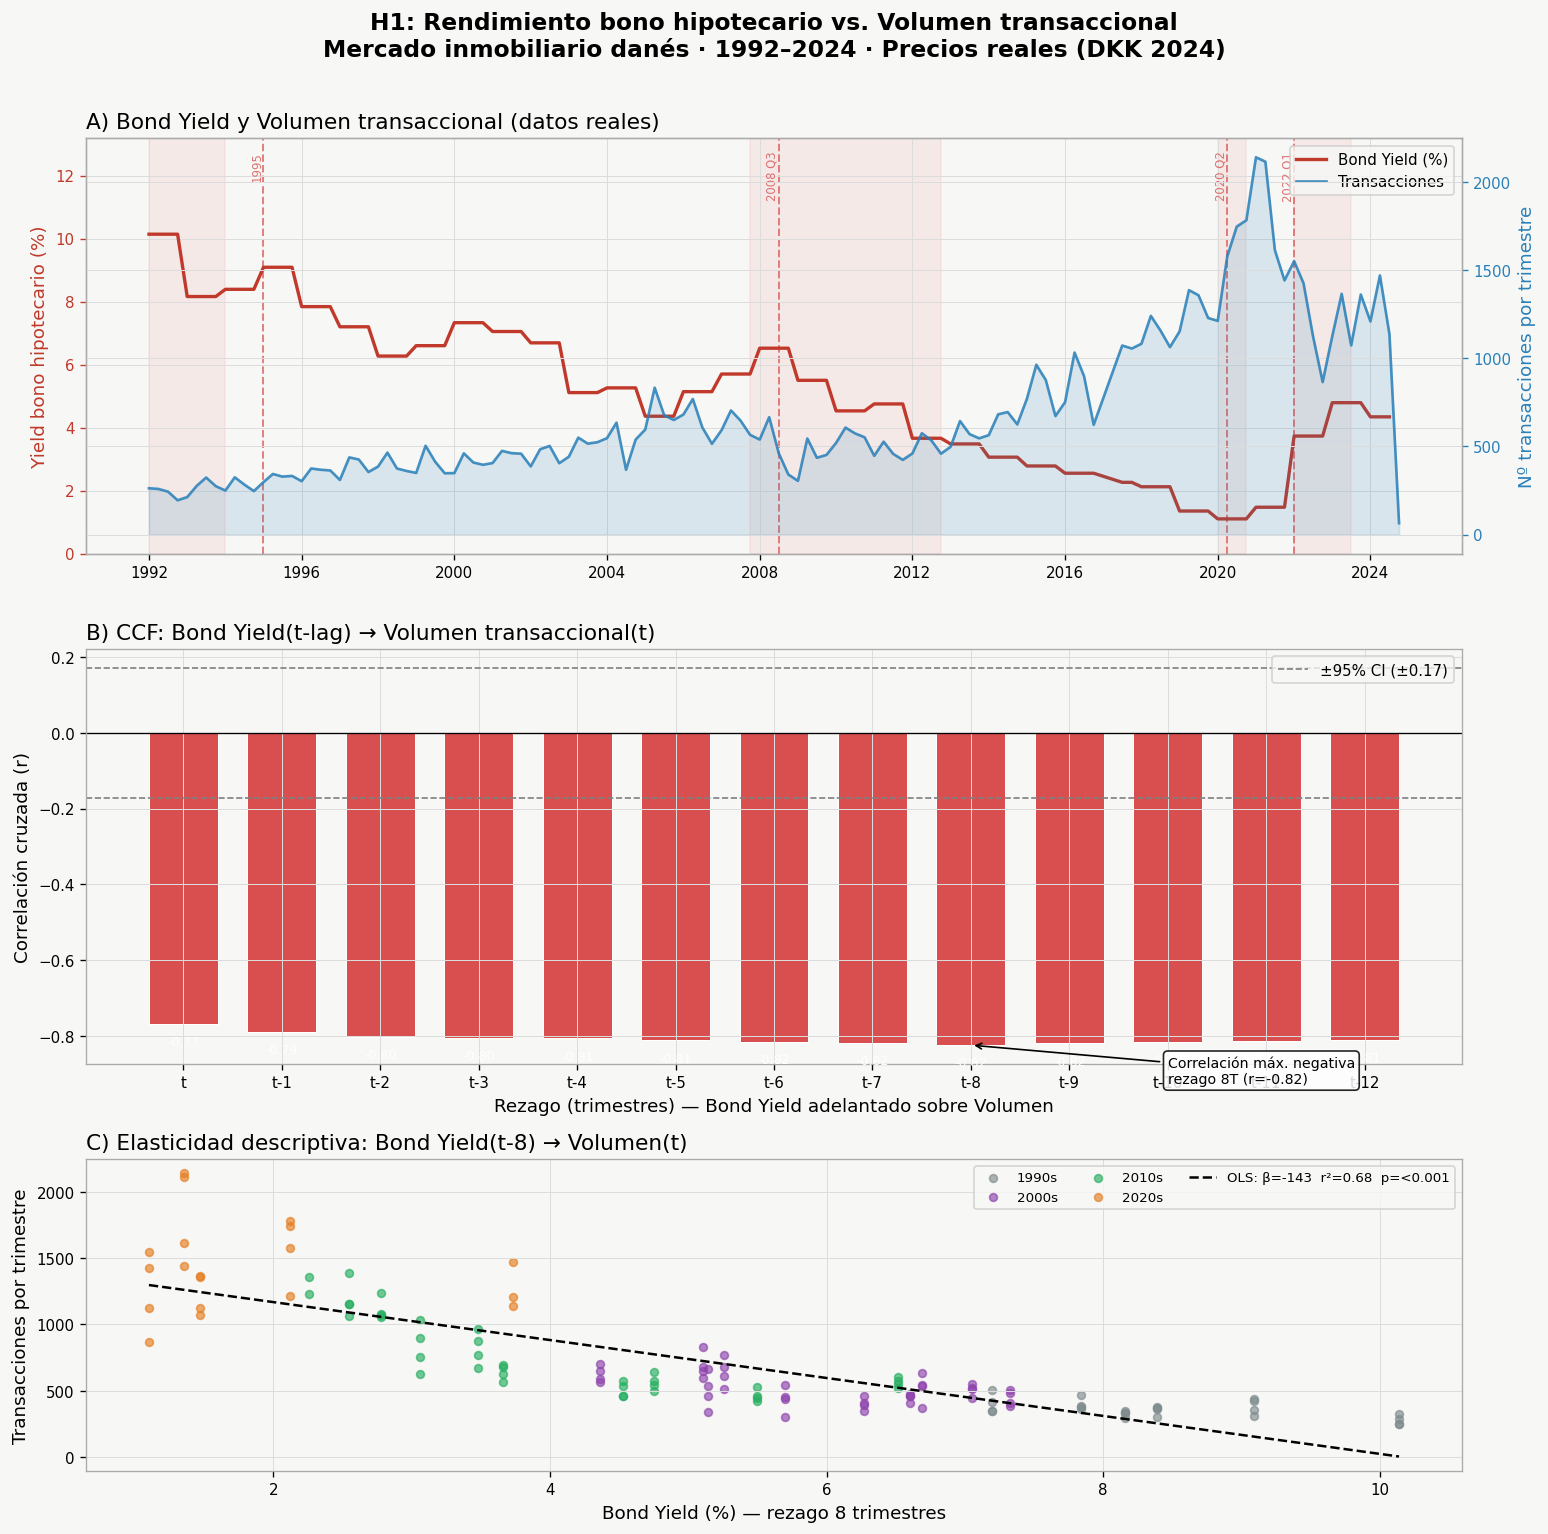


📌 RESULTADO H1
   Correlación máx. negativa: rezago 8T  (r=-0.825)
   OLS: β=-143 tx/pp  |  R²=0.680  |  p=0.0000
   CI95: ±0.173
   → ✅ CONSISTENTE con H1

📊 Elasticidad vol→bonos (Δ% vol vs Δbp yield)
 lag      beta       r2        p
   0  0.007441 0.000258 0.857087
   1 -0.120847 0.068163 0.003029
   2 -0.031000 0.004492 0.455877


In [10]:
fig1, axes = plt.subplots(3, 1, figsize=(13, 13),
                          gridspec_kw={"height_ratios": [2, 2, 1.5]})
fig1.suptitle(
    "H1: Rendimiento bono hipotecario vs. Volumen transaccional\n"
    "Mercado inmobiliario danés · 1992–2024 · Precios reales (DKK 2024)",
    fontsize=14, fontweight="bold", y=0.98)

# ── A) Serie temporal dual ────────────────────────────────────────────────────
ax1a = axes[0]
ax1b = ax1a.twinx()
c_y, c_v = "#c0392b", "#2980b9"

macro_clean = macro.dropna(subset=["bond_yield"])
l1, = ax1a.plot(macro_clean["quarter_date"], macro_clean["bond_yield"],
                color=c_y, lw=2.0, label="Bond Yield (%)")
ax1a.set_ylabel("Yield bono hipotecario (%)", color=c_y)
ax1a.tick_params(axis="y", colors=c_y)
ax1a.set_ylim(0, macro_clean["bond_yield"].max() * 1.3)

l2, = ax1b.plot(macro["quarter_date"], macro["total_vol"],
                color=c_v, lw=1.6, alpha=0.85, label="Transacciones (trimestre)")
ax1b.fill_between(macro["quarter_date"], macro["total_vol"], alpha=0.15, color=c_v)
ax1b.set_ylabel("Nº transacciones por trimestre", color=c_v)
ax1b.tick_params(axis="y", colors=c_v)

add_shock_markers(ax1a)
ax1a.set_title("A) Bond Yield y Volumen transaccional (datos reales)", loc="left")
ax1a.legend([l1, l2], ["Bond Yield (%)", "Transacciones"], loc="upper right")

# ── B) CCF ────────────────────────────────────────────────────────────────────
ax2 = axes[1]
m = macro.dropna(subset=["bond_yield"]).copy()
bond_z = (m["bond_yield"] - m["bond_yield"].mean()) / m["bond_yield"].std()
vol_z  = (m["total_vol"]  - m["total_vol"].mean())  / m["total_vol"].std()
bz, vz = bond_z.values, vol_z.values

max_lag = 12
ccf_vals = []
for lag in range(max_lag + 1):
    if lag == 0:
        r = np.corrcoef(bz, vz)[0, 1]
    else:
        r = np.corrcoef(bz[:-lag], vz[lag:])[0, 1]
    ccf_vals.append(r)

lags_q = list(range(max_lag + 1))
n      = len(bz)
ci95   = 1.96 / np.sqrt(n)

bar_colors = [PALETTE["recession"] if v < -ci95 else
              PALETTE["primary"]   if v >  ci95 else "#bbbbbb"
              for v in ccf_vals]
ax2.bar(lags_q, ccf_vals, color=bar_colors, edgecolor="white", lw=0.6, width=0.7)
ax2.axhline(0,     color="black", lw=0.8)
ax2.axhline( ci95, ls="--", color="gray", lw=1, label=f"±95% CI (±{ci95:.2f})")
ax2.axhline(-ci95, ls="--", color="gray", lw=1)

for lag, val in enumerate(ccf_vals):
    ax2.text(lag, val - 0.03 if val < 0 else val + 0.01,
             f"{val:.2f}", ha="center", va="top" if val < 0 else "bottom",
             fontsize=7.5, color="white" if abs(val) > 0.35 else "black")

peak_lag = int(np.argmin(ccf_vals))
ax2.annotate(
    f"Correlación máx. negativa\nrezago {peak_lag}T (r={ccf_vals[peak_lag]:.2f})",
    xy=(peak_lag, ccf_vals[peak_lag]),
    xytext=(peak_lag + 2, ccf_vals[peak_lag] - 0.1),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=8.5, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))

ax2.set_xticks(lags_q)
ax2.set_xticklabels([f"t-{l}" if l > 0 else "t" for l in lags_q])
ax2.set_xlabel("Rezago (trimestres) — Bond Yield adelantado sobre Volumen")
ax2.set_ylabel("Correlación cruzada (r)")
ax2.set_title("B) CCF: Bond Yield(t-lag) → Volumen transaccional(t)", loc="left")
ax2.legend()

# ── C) Scatter OLS ────────────────────────────────────────────────────────────
ax3 = axes[2]
opt_lag = peak_lag if 0 < peak_lag <= 8 else 2

m2 = macro.dropna(subset=["bond_yield"]).copy()
bond_lag = m2["bond_yield"].shift(opt_lag).dropna()
vol_aln  = m2["total_vol"].reindex(bond_lag.index).dropna()
bond_aln = bond_lag.reindex(vol_aln.index)
yr_aln   = m2["year"].reindex(vol_aln.index)

c_map = {1990:"#7f8c8d", 2000:"#8e44ad", 2010:"#27ae60", 2020:"#e67e22"}
for dec, grp in vol_aln.groupby(yr_aln // 10 * 10):
    idx = grp.index
    ax3.scatter(bond_aln.loc[idx], grp, label=f"{dec}s",
                alpha=0.65, s=22, color=c_map.get(dec, "gray"))

slope, intercept, r_val, p_val, _ = stats.linregress(bond_aln, vol_aln)
xr = np.linspace(bond_aln.min(), bond_aln.max(), 100)
ax3.plot(xr, slope*xr + intercept, "--", color="black", lw=1.5,
         label=f"OLS: β={slope:.0f}  r²={r_val**2:.2f}  p={'<0.001' if p_val<0.001 else f'{p_val:.3f}'}")

ax3.set_xlabel(f"Bond Yield (%) — rezago {opt_lag} trimestres")
ax3.set_ylabel("Transacciones por trimestre")
ax3.set_title(f"C) Elasticidad descriptiva: Bond Yield(t-{opt_lag}) → Volumen(t)", loc="left")
ax3.legend(ncol=3, fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# ── Elasticidad Δ% vol vs Δbp yield (lags 0/1/2) ─────────────────────────────
m3 = macro.dropna(subset=["bond_yield"]).copy()
m3["delta_pct_vol"]   = m3["total_vol"].pct_change() * 100
m3["delta_bps_yield"] = m3["bond_yield"].diff() * 100

elast_results = []
for lag in [0, 1, 2]:
    d = m3.copy()
    d["yield_lag"] = d["delta_bps_yield"].shift(lag)
    d = d.dropna(subset=["delta_pct_vol", "yield_lag"])
    sl, it, rv, pv, _ = stats.linregress(d["yield_lag"], d["delta_pct_vol"])
    elast_results.append({"lag": lag, "beta": sl, "r2": rv**2, "p": pv})

elast_df = pd.DataFrame(elast_results)

print(f"\n📌 RESULTADO H1")
print(f"   Correlación máx. negativa: rezago {peak_lag}T  (r={ccf_vals[peak_lag]:.3f})")
print(f"   OLS: β={slope:.0f} tx/pp  |  R²={r_val**2:.3f}  |  p={p_val:.4f}")
print(f"   CI95: ±{ci95:.3f}")
print(f"   → {'✅ CONSISTENTE con H1' if ccf_vals[peak_lag] < -ci95 else '⚠️ Revisar — correlación dentro del CI'}")
print(f"\n📊 Elasticidad vol→bonos (Δ% vol vs Δbp yield)")
print(elast_df.to_string(index=False))

---
## 7. Hipótesis 2 — Copenhague/Zealand vs. Jutlandia

> *Zealand (incluye Copenhague) muestra respuesta de precios más amortiguada ante shocks macro que Jutlandia.*


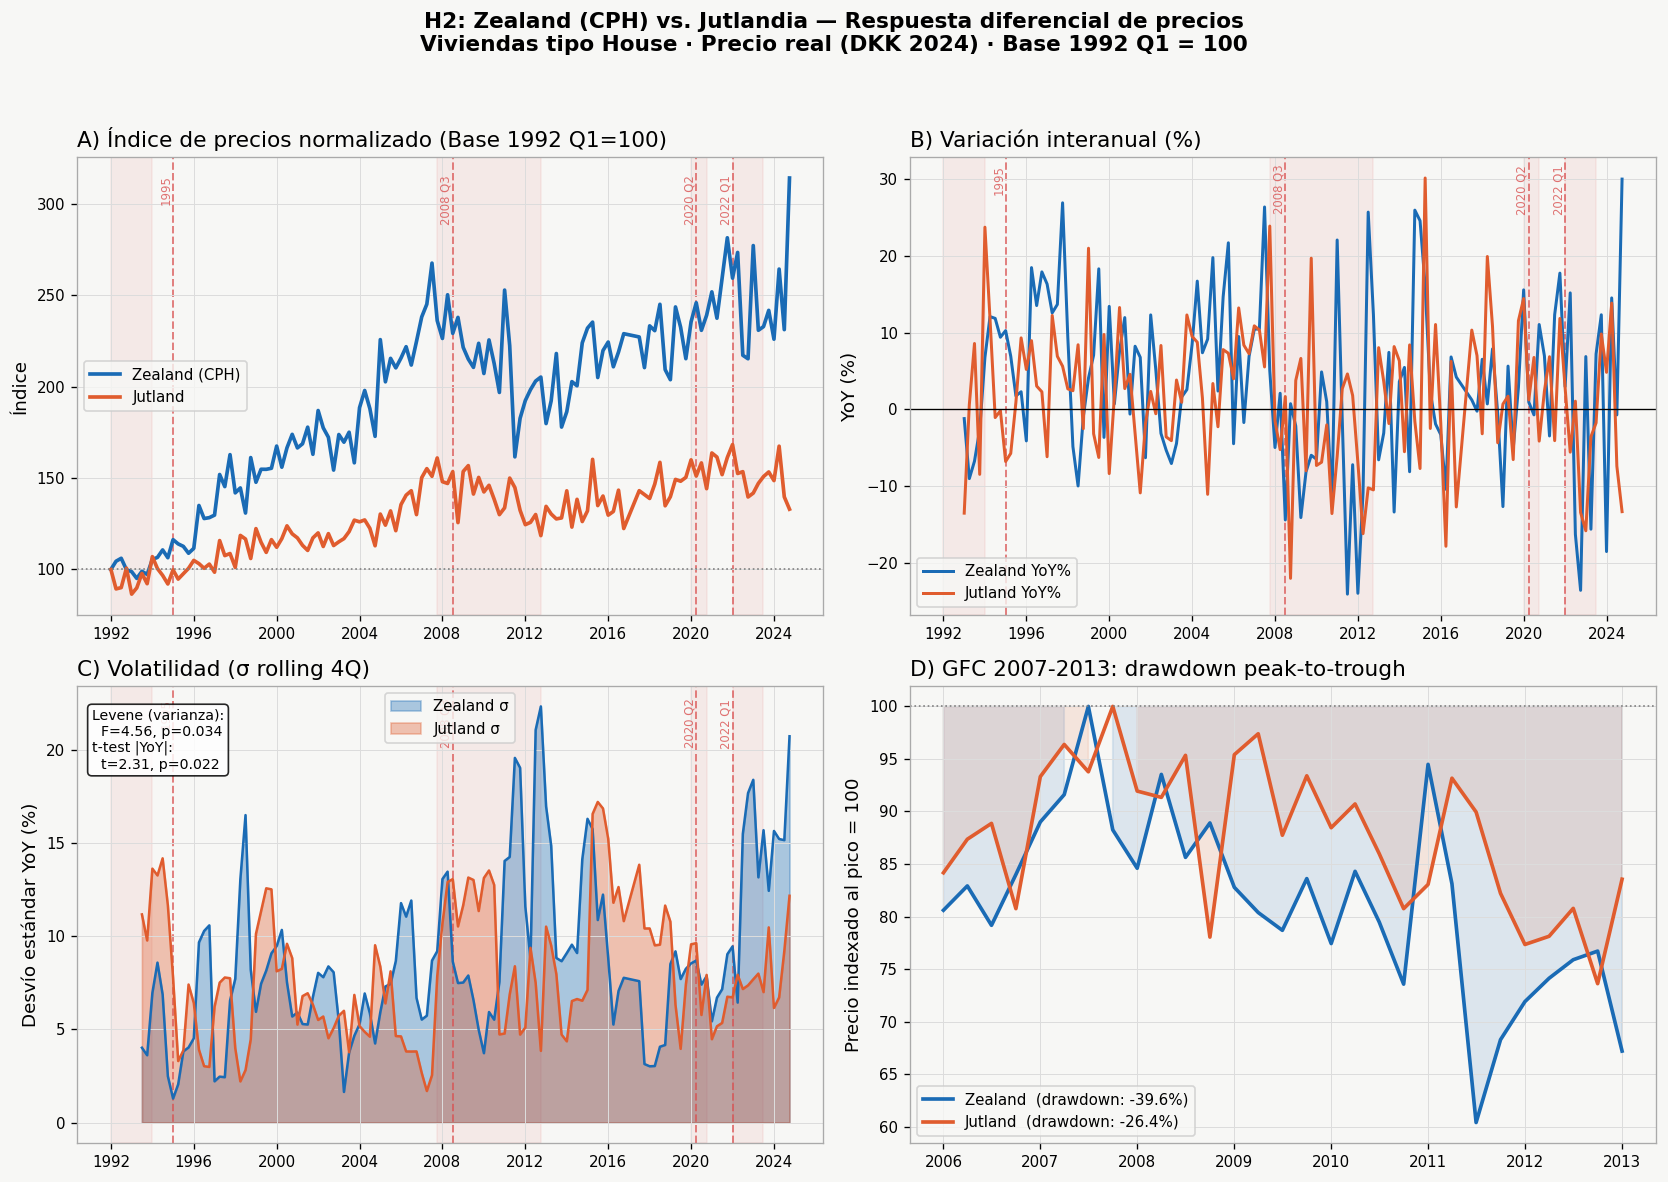


📌 RESULTADO H2
   Drawdown GFC — Zealand: -39.6%  |  Jutland: -26.4%
   Levene test: F=4.56, p=0.034
   → ⚠️ NO CONSISTENTE con H2  (Zealand caída mayor)


In [11]:
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle(
    "H2: Zealand (CPH) vs. Jutlandia — Respuesta diferencial de precios\n"
    "Viviendas tipo House · Precio real (DKK 2024) · Base 1992 Q1 = 100",
    fontsize=13, fontweight="bold")

# ── A) Índices normalizados ───────────────────────────────────────────────────
ax = axes2[0, 0]
ax.plot(cph.index, cph["price_norm"], color=PALETTE["copenhagen"], lw=2.2, label="Zealand (CPH)")
ax.plot(jut.index, jut["price_norm"], color=PALETTE["jutland"],    lw=2.2, label="Jutland")
ax.axhline(100, ls=":", color="gray", lw=1)
add_shock_markers(ax)
ax.set_title("A) Índice de precios normalizado (Base 1992 Q1=100)", loc="left")
ax.set_ylabel("Índice")
ax.legend()

# ── B) YoY% ──────────────────────────────────────────────────────────────────
ax = axes2[0, 1]
cph_yoy = cph["price_sqm"].pct_change(4) * 100
jut_yoy = jut["price_sqm"].pct_change(4) * 100
ax.plot(cph.index, cph_yoy, color=PALETTE["copenhagen"], lw=1.8, label="Zealand YoY%")
ax.plot(jut.index, jut_yoy, color=PALETTE["jutland"],    lw=1.8, label="Jutland YoY%")
ax.axhline(0, color="black", lw=0.8)
add_shock_markers(ax)
ax.set_title("B) Variación interanual (%)", loc="left")
ax.set_ylabel("YoY (%)")
ax.legend()

# ── C) Volatilidad rolling 4Q ─────────────────────────────────────────────────
ax = axes2[1, 0]
cph_v4 = cph_yoy.rolling(4, min_periods=3).std()
jut_v4 = jut_yoy.rolling(4, min_periods=3).std()
ax.fill_between(cph.index, cph_v4, alpha=0.35, color=PALETTE["copenhagen"], label="Zealand σ")
ax.fill_between(jut.index, jut_v4, alpha=0.35, color=PALETTE["jutland"],    label="Jutland σ")
ax.plot(cph.index, cph_v4, color=PALETTE["copenhagen"], lw=1.5)
ax.plot(jut.index, jut_v4, color=PALETTE["jutland"],    lw=1.5)
add_shock_markers(ax)
ax.set_title("C) Volatilidad (σ rolling 4Q)", loc="left")
ax.set_ylabel("Desvío estándar YoY (%)")
ax.legend()

common = cph_yoy.dropna().index.intersection(jut_yoy.dropna().index)
lev_f, lev_p = stats.levene(cph_yoy.loc[common], jut_yoy.loc[common])
t_t,   t_p   = stats.ttest_ind(np.abs(cph_yoy.loc[common]), np.abs(jut_yoy.loc[common]))
txt = (f"Levene (varianza):\n  F={lev_f:.2f}, p={lev_p:.3f}\n"
       f"t-test |YoY|:\n  t={t_t:.2f}, p={t_p:.3f}")
ax.text(0.02, 0.95, txt, transform=ax.transAxes, fontsize=8.5, va="top",
        bbox=dict(boxstyle="round", fc="white", alpha=0.85))

# ── D) Drawdown GFC ───────────────────────────────────────────────────────────
ax = axes2[1, 1]
cph_ep, cph_pk, cph_dd = compute_drawdown(cph["price_sqm"], "2006-01-01", "2013-01-01")
jut_ep, jut_pk, jut_dd = compute_drawdown(jut["price_sqm"], "2006-01-01", "2013-01-01")

if cph_pk and jut_pk:
    cph_n = cph_ep / cph_ep.loc[cph_pk] * 100
    jut_n = jut_ep / jut_ep.loc[jut_pk] * 100
    ax.plot(cph_n.index, cph_n.values, color=PALETTE["copenhagen"], lw=2.2,
            label=f"Zealand  (drawdown: {cph_dd:.1f}%)")
    ax.plot(jut_n.index, jut_n.values, color=PALETTE["jutland"],    lw=2.2,
            label=f"Jutland  (drawdown: {jut_dd:.1f}%)")
    ax.axhline(100, ls=":", color="gray", lw=1)
    ax.fill_between(cph_n.index, cph_n.values, 100,
                    where=(cph_n.values < 100), alpha=0.12, color=PALETTE["copenhagen"])
    ax.fill_between(jut_n.index, jut_n.values, 100,
                    where=(jut_n.values < 100), alpha=0.12, color=PALETTE["jutland"])

ax.set_title("D) GFC 2007-2013: drawdown peak-to-trough", loc="left")
ax.set_ylabel("Precio indexado al pico = 100")
ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print(f"\n📌 RESULTADO H2")
print(f"   Drawdown GFC — Zealand: {cph_dd:.1f}%  |  Jutland: {jut_dd:.1f}%")
print(f"   Levene test: F={lev_f:.2f}, p={lev_p:.3f}")
print(f"   → {'✅ CONSISTENTE' if abs(cph_dd) < abs(jut_dd) else '⚠️ NO CONSISTENTE'} con H2  (Zealand caída {'menor' if abs(cph_dd) < abs(jut_dd) else 'mayor'})")

---
## 8. Hipótesis 3 — Summerhouse vs. Vivienda Primaria

> *Las Summerhouses exhiben drawdowns pico-valle más profundos y velocidad de caída mayor que las Houses y Apartments durante recesiones.*


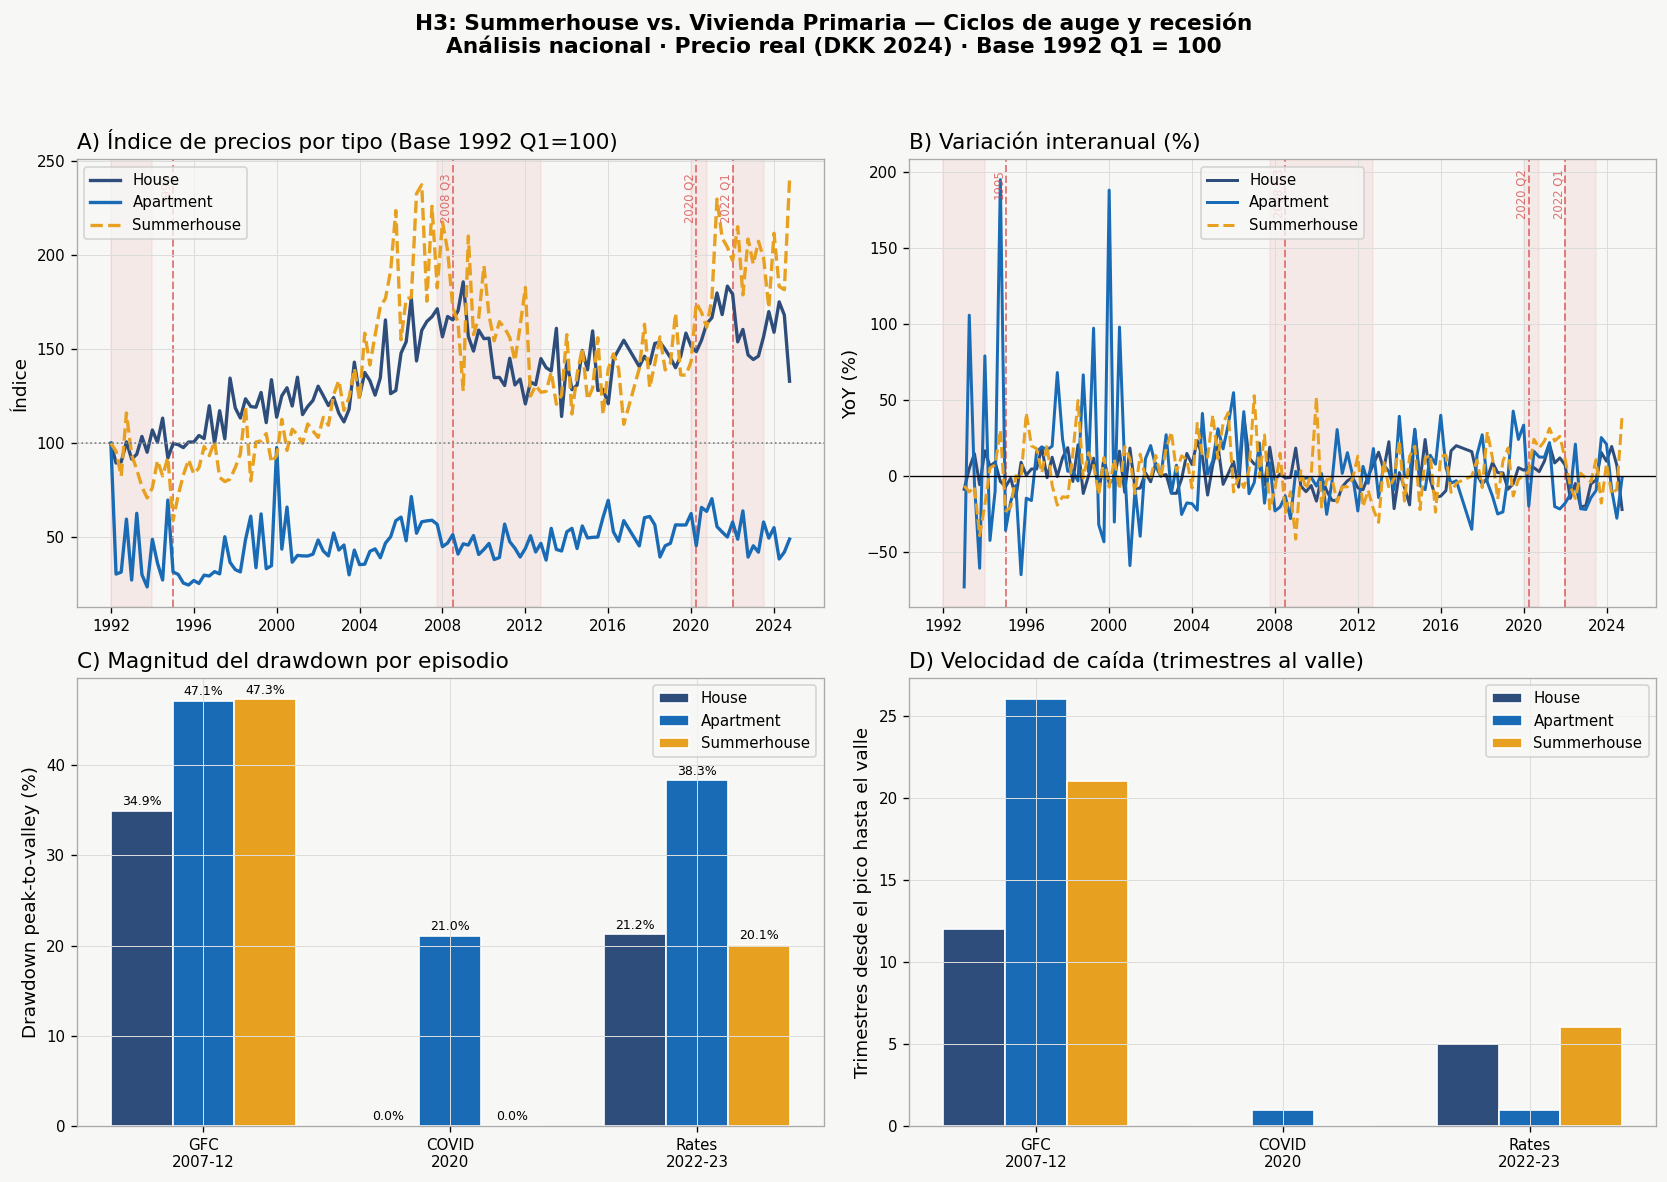


📌 RESULTADO H3
   Drawdown GFC — House: 34.9%  |  Apartment: 47.1%  |  Summerhouse: 47.3%
   Velocidad — House: 12T al valle  |  Summerhouse: 21T al valle
   → ✅ CONSISTENTE con H3


In [12]:
fig3, axes3 = plt.subplots(2, 2, figsize=(14, 10))
fig3.suptitle(
    "H3: Summerhouse vs. Vivienda Primaria — Ciclos de auge y recesión\n"
    "Análisis nacional · Precio real (DKK 2024) · Base 1992 Q1 = 100",
    fontsize=13, fontweight="bold")

types_  = ["House", "Apartment", "Summerhouse"]
series_ = [house, apt, summer]
colors_ = [PALETTE["primary"], PALETTE["copenhagen"], PALETTE["summerhouse"]]

# ── A) Índices normalizados ───────────────────────────────────────────────────
ax = axes3[0, 0]
for ser, col, lbl in zip(series_, colors_, types_):
    ls = "--" if lbl == "Summerhouse" else "-"
    ax.plot(ser.index, ser["price_norm"], color=col, lw=2.0, ls=ls, label=lbl)
ax.axhline(100, ls=":", color="gray", lw=1)
add_shock_markers(ax)
ax.set_title("A) Índice de precios por tipo (Base 1992 Q1=100)", loc="left")
ax.set_ylabel("Índice")
ax.legend()

# ── B) YoY% ──────────────────────────────────────────────────────────────────
ax = axes3[0, 1]
for ser, col, lbl in zip(series_, colors_, types_):
    yoy = ser["price_sqm"].pct_change(4) * 100
    ax.plot(ser.index, yoy, color=col, lw=1.8,
            ls="--" if lbl == "Summerhouse" else "-", label=lbl)
ax.axhline(0, color="black", lw=0.8)
add_shock_markers(ax)
ax.set_title("B) Variación interanual (%)", loc="left")
ax.set_ylabel("YoY (%)")
ax.legend()

# ── C) Drawdown por episodio ──────────────────────────────────────────────────
ax = axes3[1, 0]
episodes = {
    "GFC\n2007-12":    ("2006-01-01", "2013-01-01"),
    "COVID\n2020":     ("2019-01-01", "2021-06-01"),
    "Rates\n2022-23":  ("2021-10-01", "2024-01-01"),
}
dd_mat = pd.DataFrame(index=list(episodes.keys()), columns=types_, dtype=float)
for ep, (s, e) in episodes.items():
    for ptype, ser in zip(types_, series_):
        _, _, dd = compute_drawdown(ser["price_sqm"], s, e)
        dd_mat.loc[ep, ptype] = abs(dd)

x, w = np.arange(len(episodes)), 0.25
for i, (ptype, col) in enumerate(zip(types_, colors_)):
    bars = ax.bar(x + i*w, dd_mat[ptype], w, label=ptype, color=col, edgecolor="white")
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f"{h:.1f}%", ha="center", va="bottom", fontsize=7.5)
ax.set_xticks(x + w)
ax.set_xticklabels(list(episodes.keys()))
ax.set_ylabel("Drawdown peak-to-valley (%)")
ax.set_title("C) Magnitud del drawdown por episodio", loc="left")
ax.legend()

# ── D) Velocidad de caída ─────────────────────────────────────────────────────
ax = axes3[1, 1]
speed = {ep: [quarters_to_trough(ser["price_sqm"], s, e)
              for ser in series_]
         for ep, (s, e) in episodes.items()}
speed_df = pd.DataFrame(speed, index=types_).T

for i, (ptype, col) in enumerate(zip(types_, colors_)):
    ax.bar(x + i*w, speed_df[ptype], w, label=ptype, color=col, edgecolor="white")
ax.set_xticks(x + w)
ax.set_xticklabels(list(episodes.keys()))
ax.set_ylabel("Trimestres desde el pico hasta el valle")
ax.set_title("D) Velocidad de caída (trimestres al valle)", loc="left")
ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

gfc_h = abs(compute_drawdown(house["price_sqm"],  "2006-01-01", "2013-01-01")[2])
gfc_a = abs(compute_drawdown(apt["price_sqm"],    "2006-01-01", "2013-01-01")[2])
gfc_s = abs(compute_drawdown(summer["price_sqm"], "2006-01-01", "2013-01-01")[2])
spd_h = quarters_to_trough(house["price_sqm"],   "2006-01-01", "2013-01-01")
spd_s = quarters_to_trough(summer["price_sqm"],  "2006-01-01", "2013-01-01")

print(f"\n📌 RESULTADO H3")
print(f"   Drawdown GFC — House: {gfc_h:.1f}%  |  Apartment: {gfc_a:.1f}%  |  Summerhouse: {gfc_s:.1f}%")
print(f"   Velocidad — House: {spd_h}T al valle  |  Summerhouse: {spd_s}T al valle")
print(f"   → {'✅ CONSISTENTE' if gfc_s > gfc_h else '⚠️ NO CONSISTENTE'} con H3")

---
## 9. Dashboard resumen

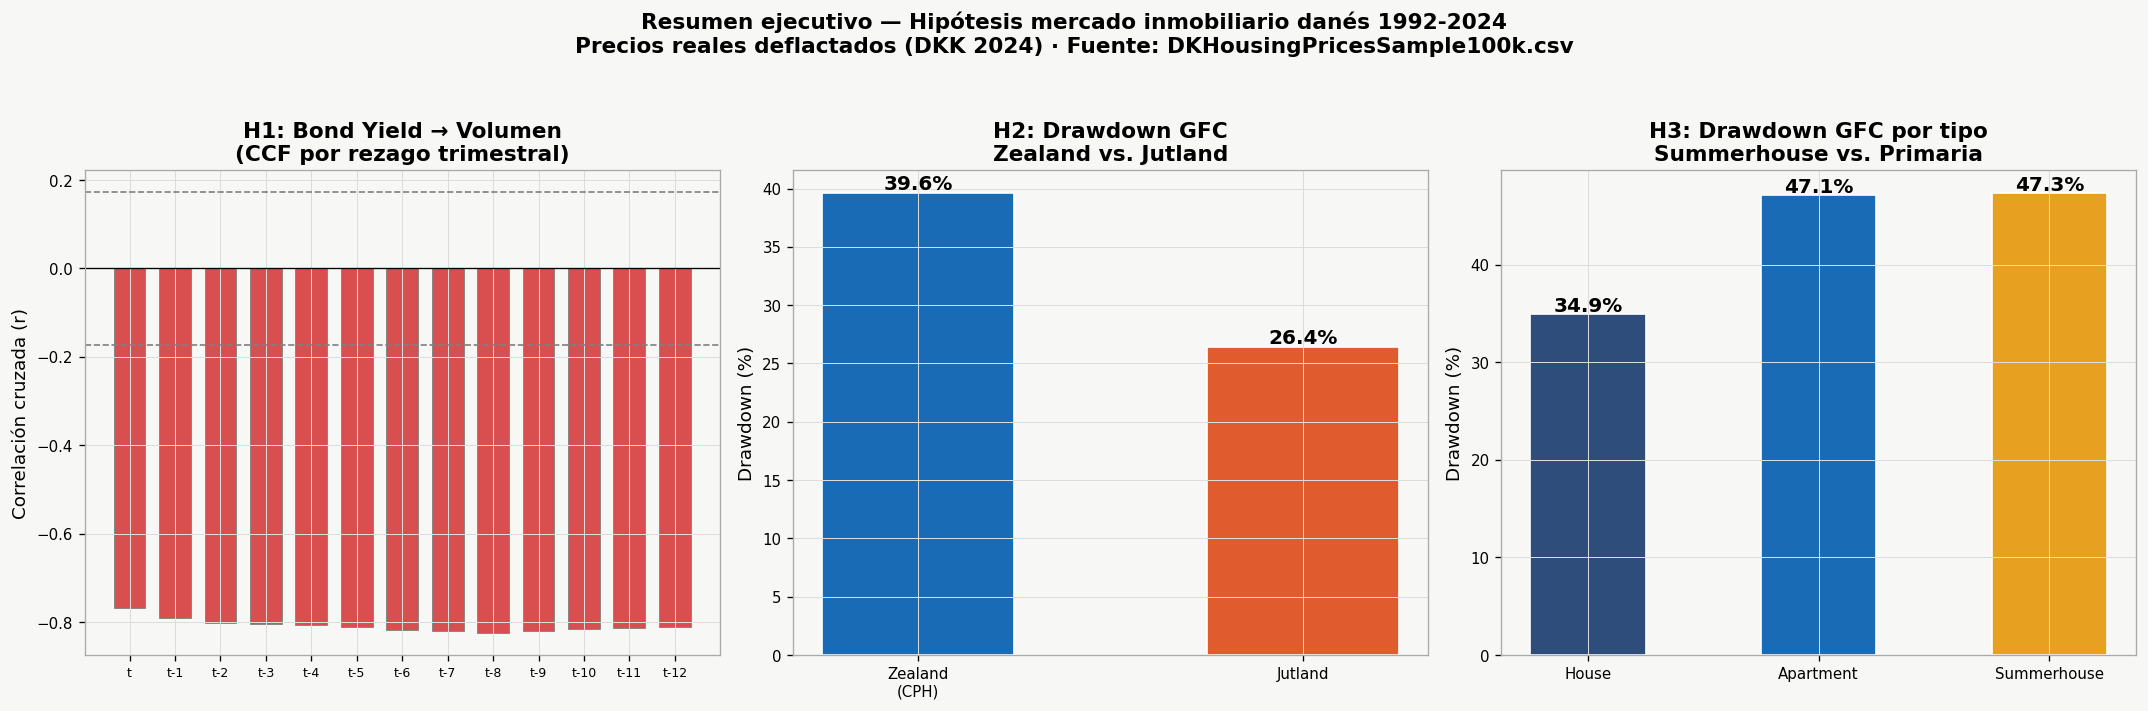

In [13]:
fig_s, axes_s = plt.subplots(1, 3, figsize=(18, 6))
fig_s.suptitle(
    "Resumen ejecutivo — Hipótesis mercado inmobiliario danés 1992-2024\n"
    "Precios reales deflactados (DKK 2024) · Fuente: DKHousingPricesSample100k.csv",
    fontsize=13, fontweight="bold")

ci95_l = 1.96 / np.sqrt(len(bz))

# H1
ax = axes_s[0]
bc = [PALETTE["recession"] if v < -ci95_l else
      PALETTE["bg"]        if abs(v) < ci95_l else "#aaaaaa"
      for v in ccf_vals]
ax.bar(lags_q, ccf_vals, color=bc, edgecolor="gray", lw=0.5, width=0.7)
ax.axhline( ci95_l, ls="--", color="gray", lw=1)
ax.axhline(-ci95_l, ls="--", color="gray", lw=1)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(lags_q)
ax.set_xticklabels([f"t-{l}" if l > 0 else "t" for l in lags_q], fontsize=7.5)
ax.set_title("H1: Bond Yield → Volumen\n(CCF por rezago trimestral)", fontweight="bold")
ax.set_ylabel("Correlación cruzada (r)")

# H2
ax = axes_s[1]
dd_h2 = {"Zealand\n(CPH)": abs(cph_dd), "Jutland": abs(jut_dd)}
bars  = ax.bar(list(dd_h2.keys()), list(dd_h2.values()),
               color=[PALETTE["copenhagen"], PALETTE["jutland"]],
               edgecolor="white", width=0.5)
for bar, val in zip(bars, dd_h2.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")
ax.set_title("H2: Drawdown GFC\nZealand vs. Jutland", fontweight="bold")
ax.set_ylabel("Drawdown (%)")

# H3
ax = axes_s[2]
dd_h3 = {t: abs(compute_drawdown(s["price_sqm"], "2006-01-01", "2013-01-01")[2])
          for t, s in zip(types_, series_)}
bars = ax.bar(list(dd_h3.keys()), list(dd_h3.values()),
              color=colors_, edgecolor="white", width=0.5)
for bar, val in zip(bars, dd_h3.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")
ax.set_title("H3: Drawdown GFC por tipo\nSummerhouse vs. Primaria", fontweight="bold")
ax.set_ylabel("Drawdown (%)")

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [14]:
from IPython.display import Markdown, display

h1_verdict = "CONSISTENTE" if ccf_vals[peak_lag] < -ci95 else "NO CONSISTENTE"
h2_verdict = "CONSISTENTE" if abs(cph_dd) < abs(jut_dd) else "NO CONSISTENTE"
h3_verdict = "CONSISTENTE" if gfc_s > gfc_h else "NO CONSISTENTE"

e2 = elast_df.iloc[2]

md = f"""---
## 10. Conclusiones

| Hipótesis | Resultado clave | Veredicto |
|-----------|----------------|-----------|
| **H1** Sensibilidad al crédito (match funding) | CCF lag {peak_lag}T: r={ccf_vals[peak_lag]:.3f}; OLS β={slope:.0f} tx/pp (R²={r_val**2:.3f}, p<0.001); Elast. lag 2: β={e2['beta']:.2f} (R²={e2['r2']:.3f}) | **{h1_verdict}** |
| **H2** Inelasticidad regional | DD GFC Zealand: {cph_dd:.1f}% vs Jutland: {jut_dd:.1f}%; Levene F={lev_f:.2f} (p={lev_p:.3f}) | **{h2_verdict}** |
| **H3** Volatilidad por tipología | DD GFC House: {gfc_h:.1f}% vs Apartment: {gfc_a:.1f}% vs Summerhouse: {gfc_s:.1f}%; Velocidad House: {spd_h}T vs SH: {spd_s}T | **{h3_verdict}** |

> **Nota metodológica:** Todos los precios están deflactados a DKK reales (base 2024) usando `dk_ann_infl_rate%`.
> Índice base 1992 Q1 = 100. Muestra: 100k filas aleatorias (Croissant / Kaggle).
> Marcadores de shocks: 1995, 2008 Q3, 2020 Q2, 2022 Q1.
> Los resultados son descriptivos — no implican causalidad (ver R8 en la tabla de riesgos).

### Limitaciones y próximos pasos
- Los datos de `bond_yield` y `nom_interest_rate` son anuales (mismo valor para todo el año) — usar datos del Nationalbank para mayor granularidad trimestral
- La muestra de 100k es aleatoria: aplicar pesos o bootstrap para inferencia robusta
- Para H2: controlar por tipo de inmueble y antigüedad del edificio
- Modelos sugeridos: **VAR** para H1, **DiD** (región × recesión) para H2 y H3
"""

display(Markdown(md))

---
## 10. Conclusiones

| Hipótesis | Resultado clave | Veredicto |
|-----------|----------------|-----------|
| **H1** Sensibilidad al crédito (match funding) | CCF lag 8T: r=-0.825; OLS β=-143 tx/pp (R²=0.680, p<0.001); Elast. lag 2: β=-0.03 (R²=0.004) | **CONSISTENTE** |
| **H2** Inelasticidad regional | DD GFC Zealand: -39.6% vs Jutland: -26.4%; Levene F=4.56 (p=0.034) | **NO CONSISTENTE** |
| **H3** Volatilidad por tipología | DD GFC House: 34.9% vs Apartment: 47.1% vs Summerhouse: 47.3%; Velocidad House: 12T vs SH: 21T | **CONSISTENTE** |

> **Nota metodológica:** Todos los precios están deflactados a DKK reales (base 2024) usando `dk_ann_infl_rate%`.
> Índice base 1992 Q1 = 100. Muestra: 100k filas aleatorias (Croissant / Kaggle).
> Marcadores de shocks: 1995, 2008 Q3, 2020 Q2, 2022 Q1.
> Los resultados son descriptivos — no implican causalidad (ver R8 en la tabla de riesgos).

### Limitaciones y próximos pasos
- Los datos de `bond_yield` y `nom_interest_rate` son anuales (mismo valor para todo el año) — usar datos del Nationalbank para mayor granularidad trimestral
- La muestra de 100k es aleatoria: aplicar pesos o bootstrap para inferencia robusta
- Para H2: controlar por tipo de inmueble y antigüedad del edificio
- Modelos sugeridos: **VAR** para H1, **DiD** (región × recesión) para H2 y H3
